# Experiment – 6 : Decision Tree Classification

---

**Name:** Shruti Hore  

**PRN:** 24070126172  

---

**Title:** Implementation of Decision Tree for Classification   

---

**Aim:** To implement and understand the Decision Tree algorithm for classification tasks and evaluate its performance on a given dataset.

---

**Objective:**

-	Understand the decision tree classification mechanism.

-	Implement the decision tree algorithm on a dataset for classification.

-	Evaluate the performance using relevant metrics such as accuracy, precision, recall, and F1-score.

-	Visualize the decision tree structure and its decision boundaries.

---

**Problem statement**

Use the given dataset(s) to demonstrate the application of the Decision Tree algorithm for classification. The task is to classify the data points into different classes based on the features and to understand how the decision tree algorithm splits the data at each node.

---

## Description
A Decision Tree is a non-parametric supervised learning algorithm used for classification and regression.

- Internal nodes → feature tests  
- Branches → outcomes  
- Leaf nodes → final prediction  

It creates a piecewise constant approximation of the target.

---

## Mathematical Formulation

### 1. Entropy
$$
Entropy(S) = - \sum_{i=1}^{c} p_i \log_2 p_i
$$

Range: $0 \leq Entropy \leq 1$

---

### 2. Information Gain
$$
IG(S, A) = Entropy(S) -
\sum_{v \in Values(A)}
\frac{|S_v|}{|S|}
Entropy(S_v)
$$

Choose attribute with maximum Information Gain.

---

### 3. Gini Index
$$
Gini(S) = 1 - \sum_{i=1}^{c} p_i^2
$$

Lower Gini ⇒ Better split.

---

## Algorithm
1. Start with full dataset.
2. Compute impurity (Entropy/Gini).
3. Choose best feature (Max IG / Min Gini).
4. Split dataset.
5. Repeat until stopping condition.

# 1. Salaries Dataset

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report, f1_score,
                             precision_score, recall_score,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

In [57]:
df = pd.read_csv('(6) salaries.csv')
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [58]:
df.shape

(16, 4)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   company                16 non-null     object
 1   job                    16 non-null     object
 2   degree                 16 non-null     object
 3   salary_more_then_100k  16 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 644.0+ bytes


In [60]:
df.describe()

,salary_more_then_100k
count,16.000
mean,0.625
std,0.500
min,0.000
25%,0.000
50%,1.000
75%,1.000
max,1.000


## Data Preprocessing

In [61]:
# separate target and features
X = df.drop('salary_more_then_100k', axis='columns')
y = df['salary_more_then_100k']

In [62]:
ip = df.drop('salary_more_then_100k', axis='columns') # x
tar = df['salary_more_then_100k'] # y

In [63]:
print("Features shape : ", X.shape)
print("Taeget shape : ", y.shape)
print("Target distribution :\n", y.value_counts)

Features shape :  (16, 3)
Taeget shape :  (16,)
Target distribution :
 <bound method IndexOpsMixin.value_counts of 0     0
1     0
2     1
3     1
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: salary_more_then_100k, dtype: int64>


In [64]:
# encode categorical data using label encoder
LE = LabelEncoder()

# fit and transform
X['company_encoded'] = LE.fit_transform(X['company'])
X['job_encoded'] = LE.fit_transform(X['job'])
X['degree_encoded'] = LE.fit_transform(X['degree'])

In [65]:
X_en = X[['company_encoded', 'job_encoded', 'degree_encoded']]

print("Encoded Features :\n", X_en.head())


Encoded Features :
    company_encoded  job_encoded  degree_encoded
0                2            2               0
1                2            2               1
2                2            0               0
3                2            0               1
4                2            1               0


## Train DT

In [66]:
model = DecisionTreeClassifier(random_state=34)
model.fit(X_en, y)

DecisionTreeClassifier(random_state=34)

In [67]:
acc = model.score(X_en, y)
print(f"Training Accuracy : {acc:.4f}")

Training Accuracy : 1.0000


making predictions

In [68]:
# example predictions
test_cases = [
    [2, 1, 0],
    [2, 1, 1],
    [1, 2, 2]
]

test_labels = [
    "Google, Computer Engineer, Bachelor's",
    "Google, Computer Engineer, Master's",
    "Apple, Manager, PhD"
]

for case, label in zip(test_cases, test_labels):
    pred = model.predict([case])[0]
    print(f"{label}: Salary > 100k? {pred} ({'yes' if pred == 1 else 'no'})")

Google, Computer Engineer, Bachelor's: Salary > 100k? 0 (no)
Google, Computer Engineer, Master's: Salary > 100k? 1 (yes)
Apple, Manager, PhD: Salary > 100k? 1 (yes)


# 2. Iphone Purchase

In [69]:
data = pd.read_csv('(6) iphone_purchase_records.csv')
data.head()

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [70]:
data.shape

(400, 4)

In [71]:
data.dtypes

Gender             object
Age                 int64
Salary              int64
Purchase Iphone     int64
dtype: object

In [72]:
data.isnull().sum()

Gender             0
Age                0
Salary             0
Purchase Iphone    0
dtype: int64

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   Salary           400 non-null    int64 
 3   Purchase Iphone  400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


In [74]:
# Feature Selection
X = data.iloc[: , :-1].values # all columns except last (purchase ie target)
y = data.iloc[: , 3].values   # last column

In [75]:
print("Features shape :", X.shape)
print("Targets shape : ", y.shape)

Features shape : (400, 3)
Targets shape :  (400,)


In [76]:
# encode gender column
LE = LabelEncoder()
X[:, 0] = LE.fit_transform(X[:,0])

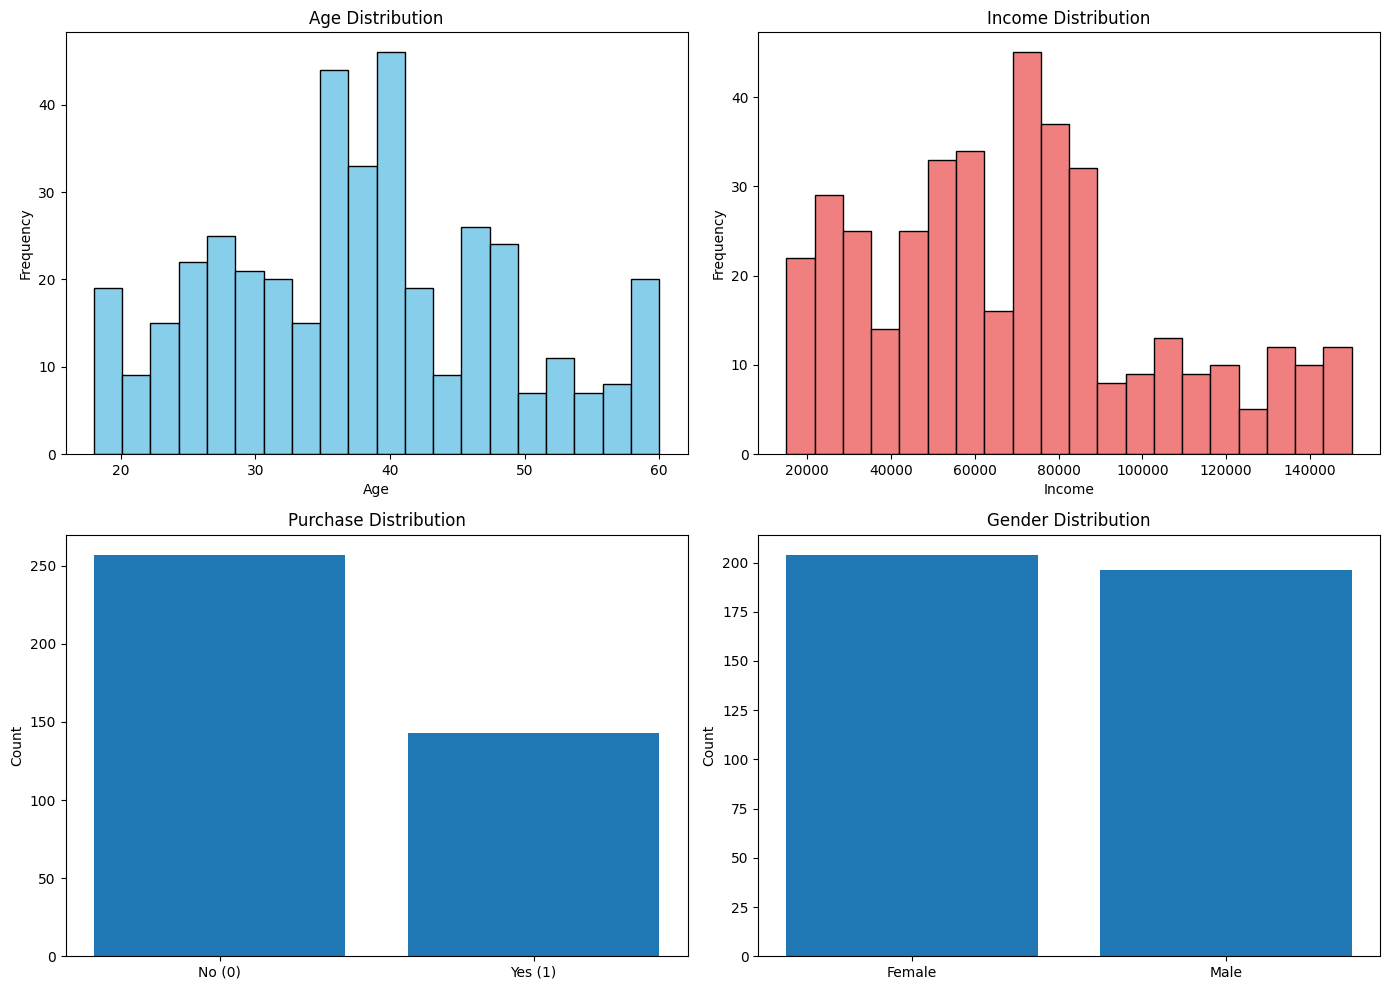

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
 
# Age distribution
axes[0, 0].hist(X[:, 1], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
 
# Income distribution
axes[0, 1].hist(X[:, 2], bins=20, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlabel('Income')
axes[0, 1].set_ylabel('Frequency')
 
# Purchase distribution
axes[1, 0].bar(['No (0)', 'Yes (1)'], np.bincount(y))
axes[1, 0].set_title('Purchase Distribution')
axes[1, 0].set_ylabel('Count')
 
# Gender distribution
gender_counts = np.bincount(X[:, 0].astype(int))
axes[1, 1].bar(LE.classes_, gender_counts)
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_ylabel('Count')
 
plt.tight_layout()

In [78]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=38)

In [79]:
# Train Decision Tree (Gini)
DTC_gini = DecisionTreeClassifier(criterion='gini')
DTC_gini.fit(X_train, y_train)

train_acc_gini = DTC_gini.score(X_train, y_train)
test_acc_gini = DTC_gini.score(X_test, y_test)

print(f"Training accuracy (gini) : {train_acc_gini:.4f}")
print(f"Testing accuracy (gini) : {test_acc_gini:.4f}")

Training accuracy (gini) : 1.0000
Testing accuracy (gini) : 0.8900


In [80]:
# Train Decision Tree (Entropy)
DTC_entropy = DecisionTreeClassifier(criterion='entropy')
DTC_entropy.fit(X_train, y_train)

train_acc_entropy = DTC_entropy.score(X_train, y_train)
test_acc_entropy = DTC_entropy.score(X_test, y_test)

print(f"Training accuracy (entropy) : {train_acc_entropy:.4f}")
print(f"Testing accuracy (entropy) : {test_acc_entropy:.4f}")

Training accuracy (entropy) : 1.0000
Testing accuracy (entropy) : 0.8900


In [81]:
comparison_df = pd.DataFrame({
    'Criterion': ['Gini', 'Entropy'],
    'Train Accuracy': [train_acc_gini, train_acc_entropy],
    'Test Accuracy': [test_acc_gini, test_acc_entropy]
})
print(comparison_df)

  Criterion  Train Accuracy  Test Accuracy
0      Gini             1.0           0.89
1   Entropy             1.0           0.89


In [82]:
DTC = DTC_gini
y_pred = DTC.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix :\n", cm)

Confusion Matrix :
 [[55  7]
 [ 4 34]]


In [83]:
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8900
Precision : 0.8293
Recall : 0.8947
F1 Score : 0.8608


In [84]:
print(f"Classification Report : ")
print(classification_report(y_test, y_pred, target_names=['No Purchase (0)', 'Purchase (1)']))

Classification Report : 
                 precision    recall  f1-score   support

No Purchase (0)       0.93      0.89      0.91        62
   Purchase (1)       0.83      0.89      0.86        38

       accuracy                           0.89       100
      macro avg       0.88      0.89      0.88       100
   weighted avg       0.89      0.89      0.89       100



Text(0.5, 1.0, 'Decision Tree - Full Structure')

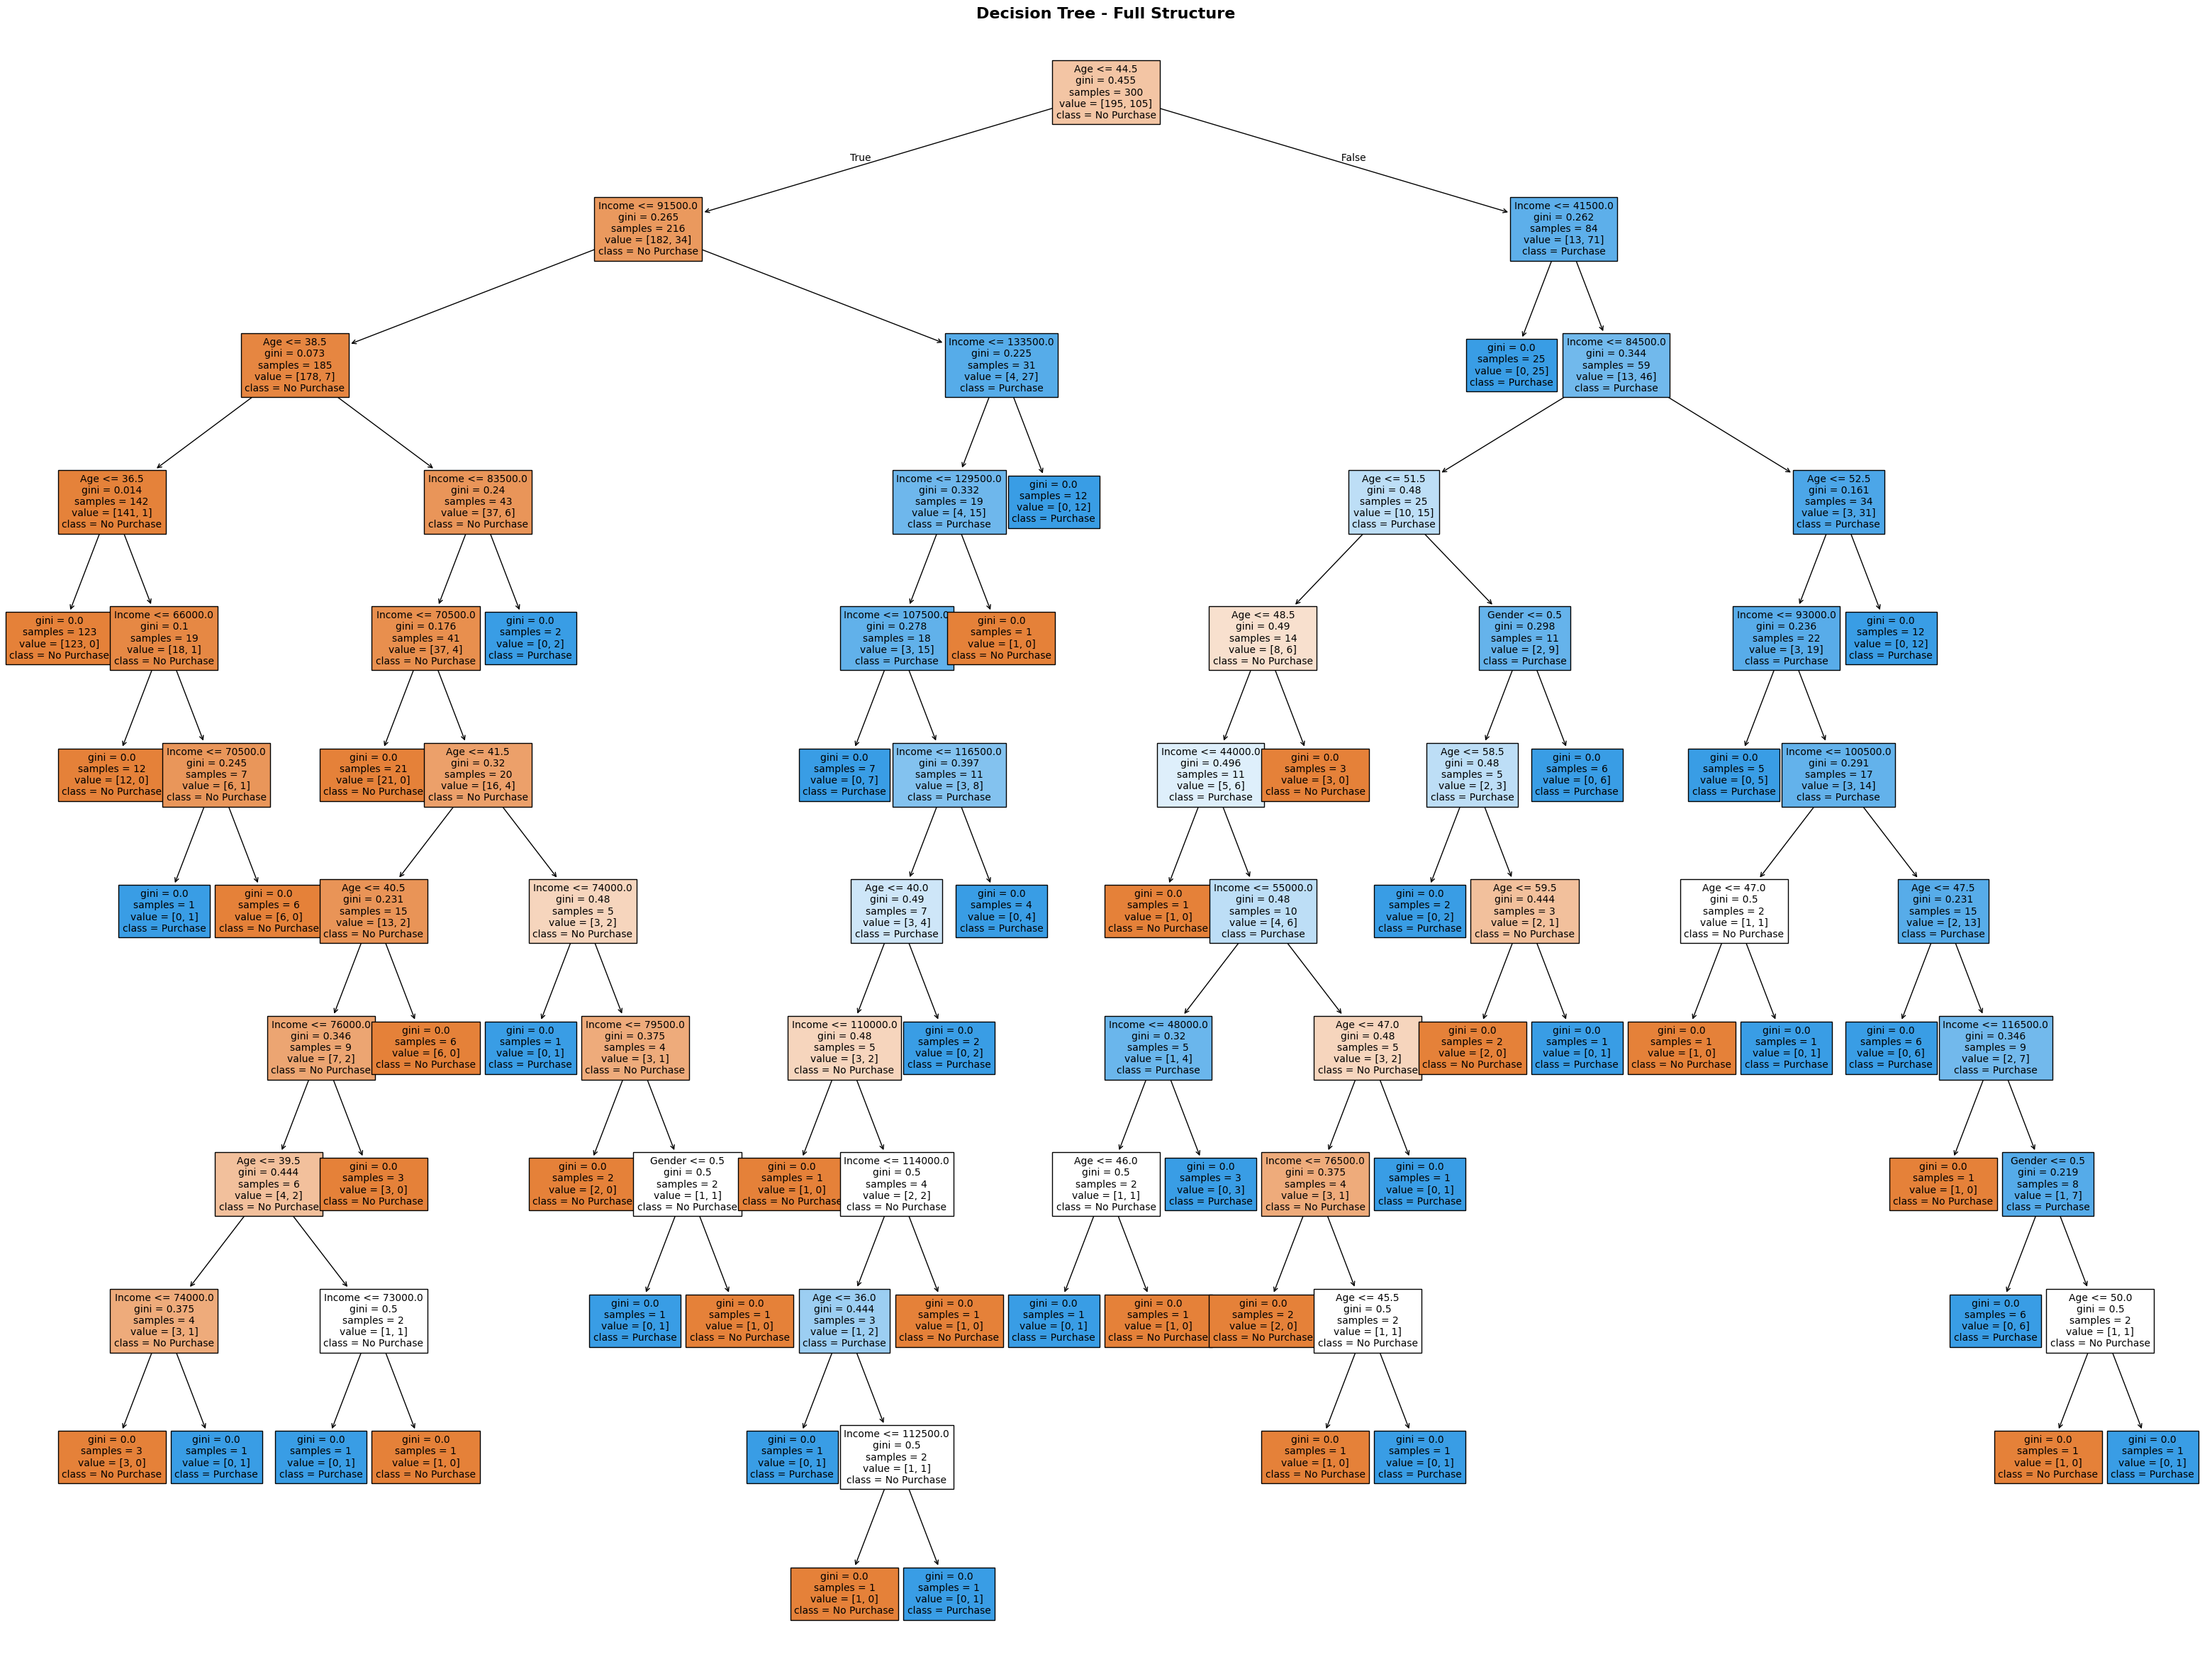

In [85]:
# Full tree
plt.figure(figsize=(40, 30))
plot_tree(DTC, filled=True, feature_names=['Gender', 'Age', 'Income'],
          class_names=['No Purchase', 'Purchase'], fontsize=10)
plt.title('Decision Tree - Full Structure', fontsize=16, fontweight='bold')

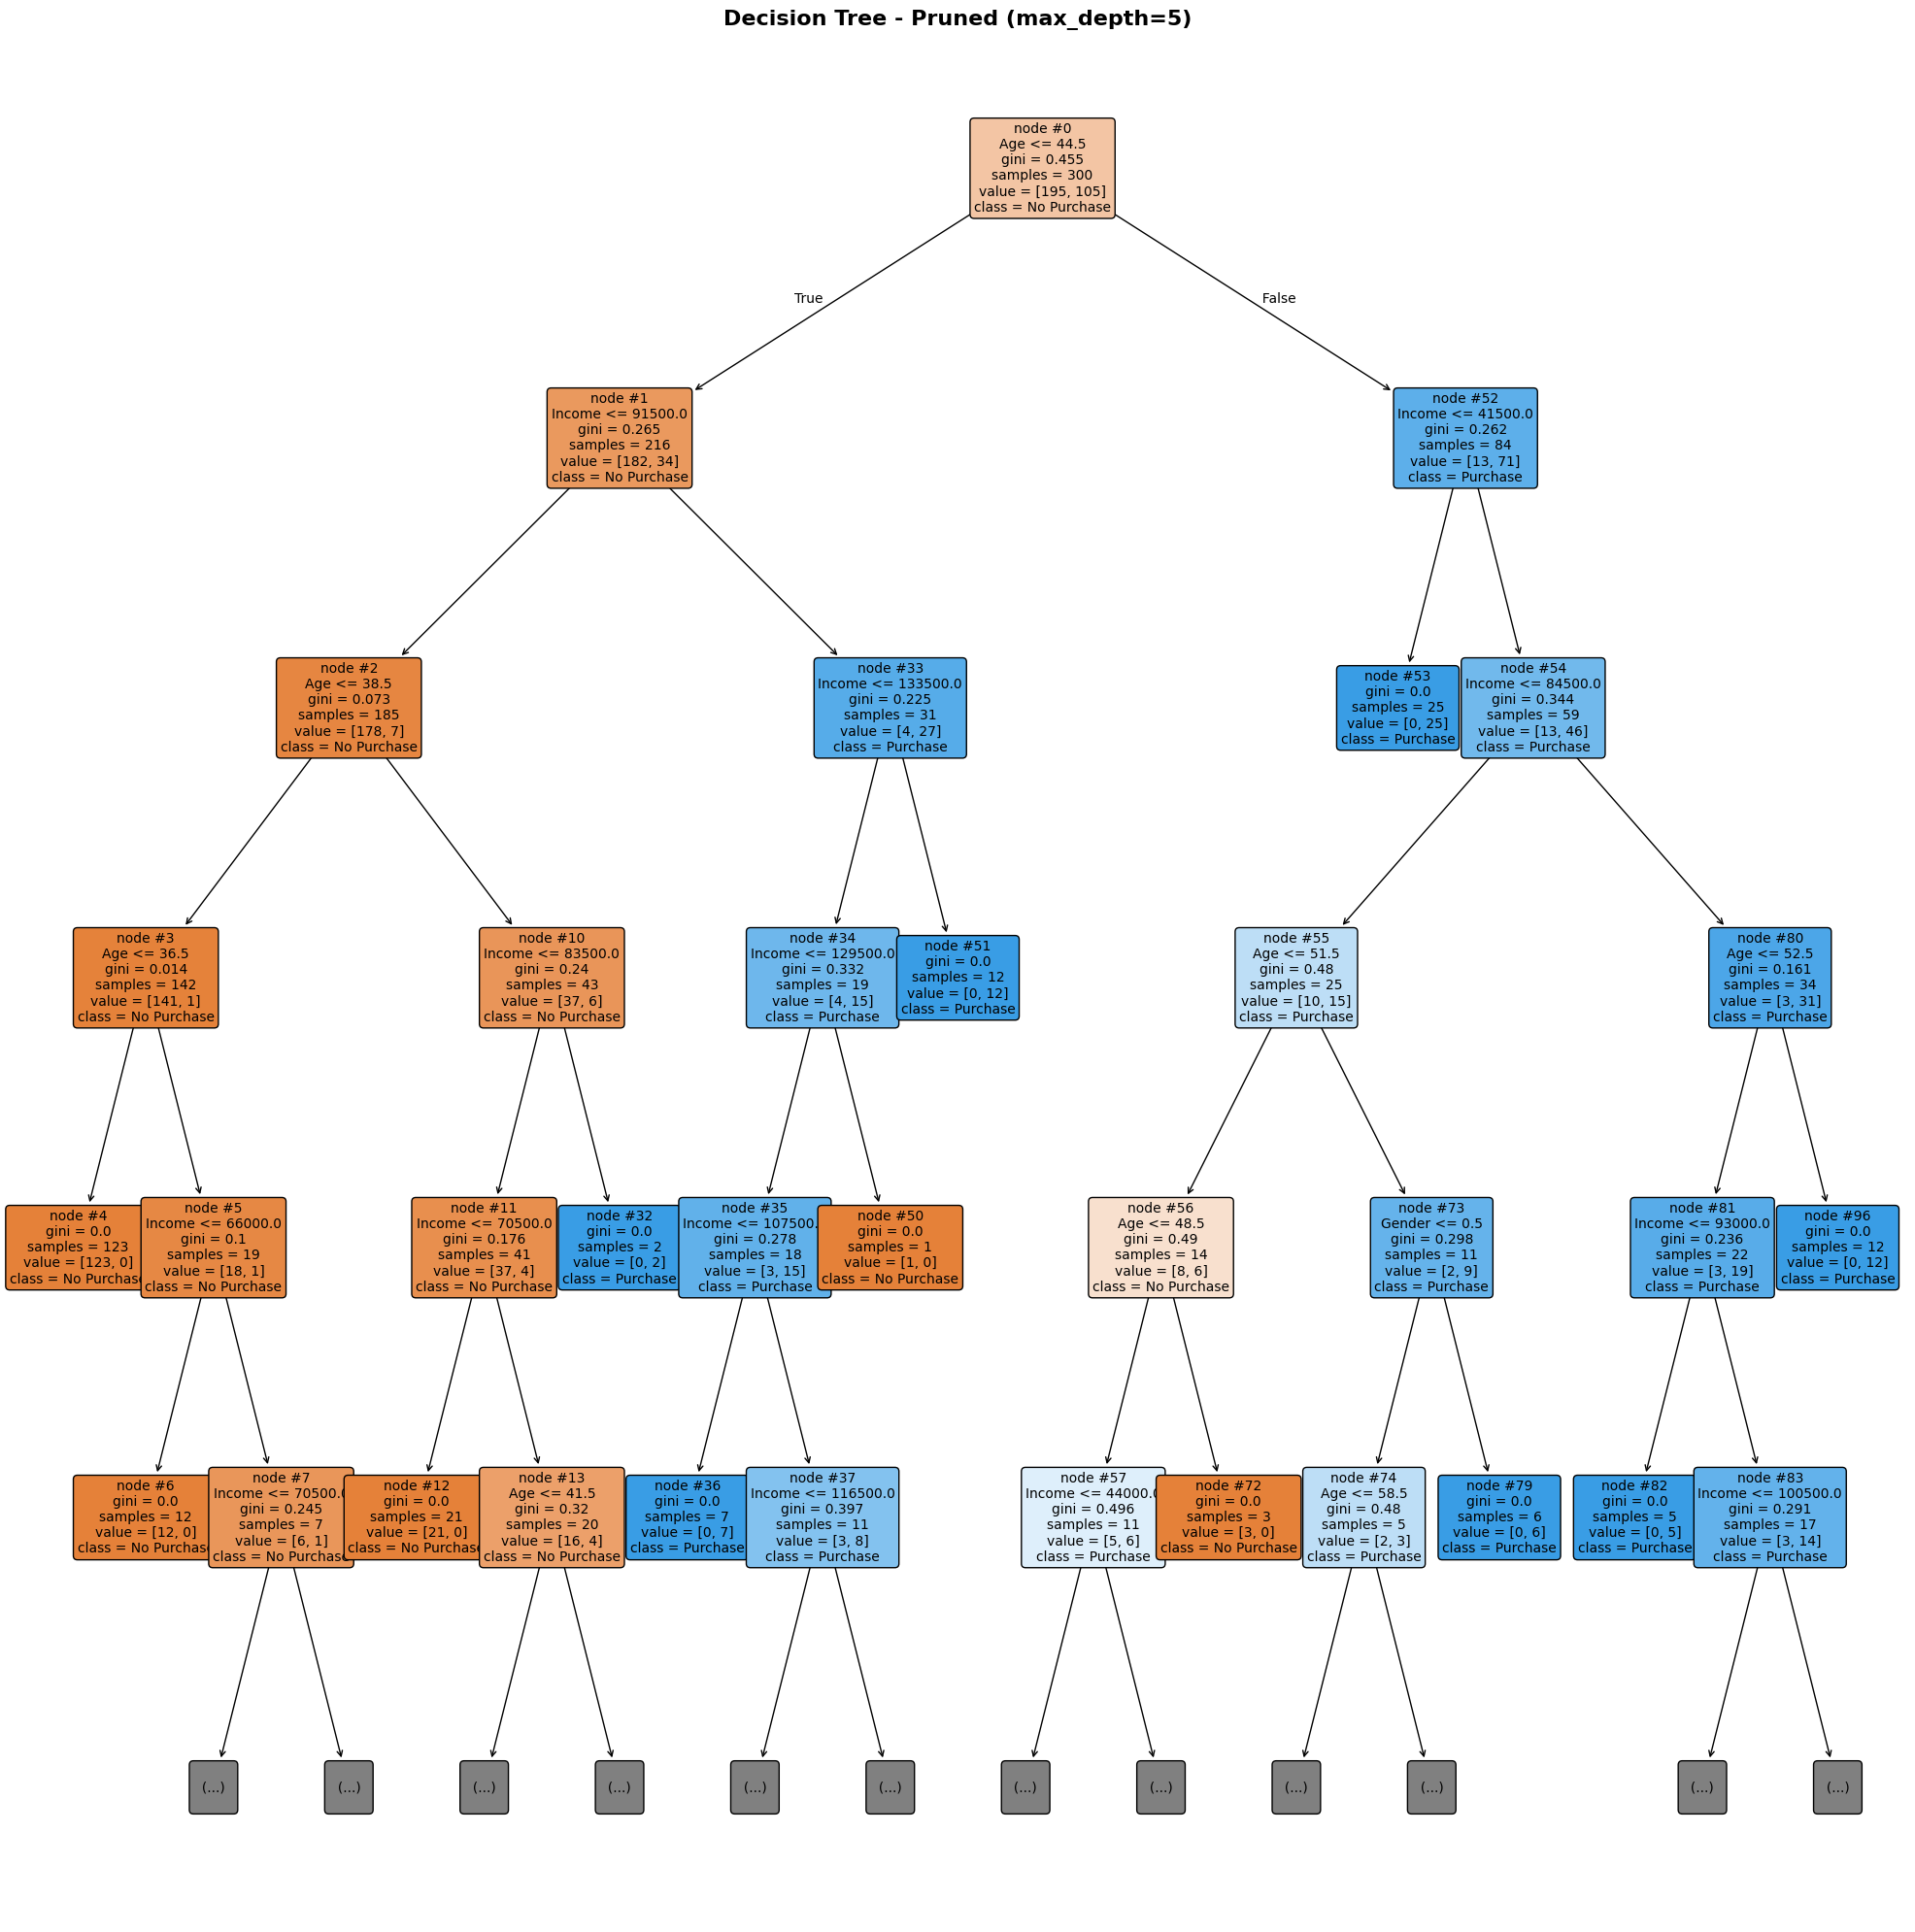

In [86]:
# Pruned tree (max_depth=5)
plt.figure(figsize=(20,20))
plot_tree(DTC, filled=True, max_depth=5, node_ids=True, rounded=True,
          feature_names=['Gender', 'Age', 'Income'],
          class_names=['No Purchase', 'Purchase'], fontsize=10)
plt.title('Decision Tree - Pruned (max_depth=5)', fontsize=16, fontweight='bold')
plt.tight_layout()

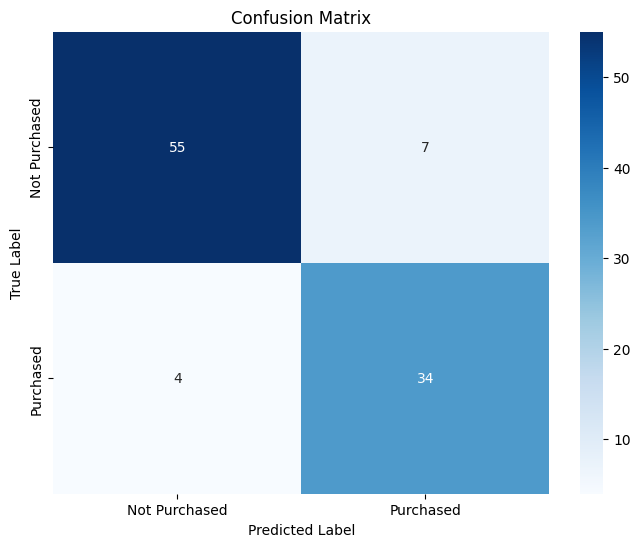

In [87]:
# Confusion Matrix Heatmap
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True, cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Conclusion
Decision Trees use Entropy or Gini to reduce impurity and build interpretable models.  
Proper hyperparameter tuning prevents overfitting and underfitting.